# Practice 1 — From Data to Graphs: Zachary's Karate Club

### Complex Network Features: Nodes, Edges, Adjacency, Clustering Coefficient, NetworkX, Visualization

**Subject:** Social Networks (SNET)  
**Language:** English  
**Main libraries:** pandas, NetworkX, Matplotlib

## Objectives of the practice

1. Work with a real social-network database: **Zachary's Karate Club**.
2. Use **Python `pandas`** to read, inspect, and summarize an edge-list dataset.
3. Convert tabular relational data into a graph using **NetworkX**.
4. Understand and apply the following Complex Network concepts:
   - nodes,
   - edges,
   - adjacency,
   - clustering coefficient,
   - graph visualization.
5. Interpret what the resulting graph tells us about the social structure of the club.

The final objective is not merely to draw a graph, but to explain how a relational dataset becomes a mathematical network and what structural information can be extracted from it.

### References and data source

- Zachary, W. W. (1977). *An Information Flow Model for Conflict and Fission in Small Groups*. Journal of Anthropological Research, 33(4), 452–473.


## 1. Description of the problem

### Objective

A conventional table describes observations using rows and columns. A **network dataset** instead emphasizes relationships between entities.

In this practice we will study a friendship/interactions network among the members of a university karate club observed by Wayne W. Zachary. Each member is represented by a node, and a social relation between two members is represented by an edge.

The main questions are:

1. How can relational data stored in a table be converted into a graph?
2. How many nodes and edges does the network contain?
3. Which members are adjacent?
4. Do the members' contacts tend to be mutually connected, forming triangles?
5. What can we learn by visualizing the network?

### <font color="blue"><b>1.1. The database: Zachary's Karate Club</b></font>

Zachary's Karate Club is a classic Social Network Analysis dataset. Wayne W. Zachary observed a university karate club during 1970–1972. A conflict between the instructor ("Mr. Hi") and the club administrator ("John A.") eventually caused the club to split into two factions. Zachary recorded social interactions among club members outside formal classes.

| Property | Value |
|---|---|
| Nodes | 34 club members |
| Edges | 78 social ties |
| Type | Undirected, unweighted |
| Ground-truth communities | 2 factions after the split |
| Classic reference | Zachary (1977) |

The network is **undirected**: if member A is connected to member B, the same relationship connects B to A.

For this first practice, we focus on the topology of the network rather than on predicting the final split.



### <font color="blue"><b>1.2. Complex Network features used in this practice</b></font>

| Feature | Short explanation |
|---|---|
| **Node** | An entity in the network. Here, each node is one karate-club member. |
| **Edge** | A relationship between two nodes. Here, an edge indicates a social tie/interactions between two members. |
| **Adjacency** | Two nodes are adjacent when an edge directly connects them. The adjacency matrix records this information for every pair of nodes. |
| **Clustering coefficient** | Measures how strongly a node's neighbors are connected to one another. In a social network, it captures the idea that “my friends are also friends with each other.” |
| **NetworkX** | A Python library for creating, manipulating, measuring, and visualizing graphs and complex networks. |
| **Visualization** | A graphical representation of nodes and edges. Layout algorithms place nodes in the plane so that structural patterns can be inspected visually. |


## <font color="red"><b>Exercise 1</b></font>

1. In one paragraph, explain why the Karate Club data should be represented as a **network** rather than only as a conventional table.
2. Identify what the **nodes** and **edges** represent.
3. Explain why the graph should be considered **undirected**.

## <font color="green"><b>Exercise 1</b></font>

1. The Karate Club data should be represented as a network because we want to focus on the relationships between the members, not only on their individual values or information. A network makes it easier to represent and analyze who is connected to whom.
2. Every person in the Karate Club is a node, and the edges are the interactions between the members
3. Because when there is an interaction between person A and person B, for example, when person A talks to person B, by definition person B is also interacting with person A, it is mutual.

## Examples of graphs (illustrations)

**Friends in a class (social network)**

- Nodes: students (one node per student).
- Edges: an undirected edge indicates a friendship or regular interaction between two students.
- Typical properties: unweighted, undirected; degree = number of friends; clustering shows how tight friendship groups are.

Small edge-list example:

| source | target |
|---:|---:|
| Alice | Bob |
| Alice | Carol |
| Bob | Carol |
| Dan | Eve |

This encodes a triangle among Alice/Bob/Carol and an independent pair Dan–Eve.

**Electricity distribution between Spanish cities (infrastructure network)**

- Nodes: cities or substations (e.g., Madrid, Barcelona, Sevilla).
- Edges: transmission lines connecting nodes; edges are often weighted by capacity (MW) or distance (km).
- Typical properties: sparse topology, edges may have attributes (`capacity`, `length`); reliability/redundancy are important for network resilience.

Small illustrative edge-list (with capacities):

| source | target | capacity_MW |
|---:|---:|---:|
| Madrid | Toledo | 500 |
| Madrid | Valladolid | 800 |
| Sevilla | Malaga | 300 |

Here adjacency entries are mostly zero; a `1` (or the weight) indicates a direct transmission connection.


## <font color="red"><b>Exercise 2</b></font>

In order to clarify ideas, for each example above:

1. Identify the *nodes* and *edges* explicitly.
2. State whether the network is directed or undirected, and whether edges are weighted.
3. Write the small example in edge-list form and draw the corresponding graph.
4. For one chosen node, list its adjacent nodes (i.e., the row in the adjacency matrix that is nonzero).

## <font color="green"><b>Exercise 2</b></font>

1. The nodes for "Friends in a class" are the following: Alice, Bob, Carol, Dan and Eve, and the edges are Alice-Bob, Alice-Carol, Bob-Carol and Dan-Eve.
1. The nodes for "Electiricty" are the following: Madrid, Toledo, Valladolid, Sevilla and Malaga, and the edges are Madrid-Toledo with a weight of 500, Madrid-Valladolid, with a weight of 800 and Sevilla-Malaga with a weight of 300.
2. Both networks are undirect because electricity connections lines have not directions, are full-duplex, and human interactions are mutual has said before. Human interactions in this example is not weighted beacuse they don't tell us any whay to mesure the level of interaction, and for electricity is weighted beacuse the transimission line has a capacity measured in MW.
3. 
| source | target |
|---:|---:|
| Alice | Bob |
| Alice | Carol |
| Bob | Carol |
| Dan | Eve |

      Alice
      /   \
     /     \
   Bob-----Carol

   Dan-----Eve

| source | target | capacity_MW |
|---:|---:|---:|
| Madrid | Toledo | 500 |
| Madrid | Valladolid | 800 |
| Sevilla | Malaga | 300 |

Toledo  -------- Madrid -------- Valladolid
           500             800

Sevilla -------- Malaga
          300

4. The adjacent nodes of Alice are Bob and Carol. And for electricity, the adjacent nodes of Madrid are Valladolid and Toledo.

# 3. Practical part

### First we load the Python libraries
### Then we read and inspect the database using `pandas`
### Finally we construct and analyze the graph with `NetworkX`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### 3.1. Reading the database with pandas

Because the dataset is available as a CSV file, `pandas.read_csv()` can read it directly from the URL.

In [2]:
File = "karate.csv"

edges = pd.read_csv(File)

# Display the first rows
edges.head()

,from,to
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


### 3.2. Inspect the database

Before constructing a graph, we inspect the table exactly as we would in an Exploratory Data Analysis (EDA).

In [3]:
print("Shape of the edge table:", edges.shape)
print("\nColumns:")
print(list(edges.columns))

print("\nData types:")
print(edges.dtypes)

print("\nMissing values:")
print(edges.isna().sum())

print("\nFirst five rows:")
display(edges.head())

Shape of the edge table: (78, 2)

Columns:
['from', 'to']

Data types:
from    str
to      str
dtype: object

Missing values:
from    0
to      0
dtype: int64

First five rows:


,from,to
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


## <font color="red"><b>Exercise 3</b></font>

1. What does one **row** of this DataFrame represent?
2. How many observations (rows) are in the edge list?
3. Are there missing values?
4. Why do we not interpret the number of rows as the number of people?

## <font color="green"><b>Exercise 3</b></font>

1. One row represents an edge, a interaction between person A and person B.
2. 78 observations.
3. No.
4. Because there are repetitions, a lot of people can interact with the same people, for example if person A interacts with person B, person C and person D and then all of them interact bewtween them, we have only 4 people but we will have more than 4 edges.

### 3.3. Standardize the column names

The source file uses the columns `from` and `to`. We rename them to `source` and `target`, which makes the semantics explicit and is convenient when creating the graph.

In [4]:
edges = edges.rename(columns={"from": "source", "to": "target"})

edges.head()

,source,target
0,Mr Hi,Actor 2
1,Mr Hi,Actor 3
2,Mr Hi,Actor 4
3,Mr Hi,Actor 5
4,Mr Hi,Actor 6


### 3.4. Exploratory Data Analysis of the relational table

**Always check**

**<font color="red"><b>Non</b></font>  acceptable conditions**: duplicates and self-loops


- A **duplicate edge** would repeat the same relationship.
- A **self-loop** is an edge from a node to itself, $(u,u)$.

For this social network, we expect an undirected simple graph without self-loops.

In [5]:
# Duplicate rows
n_duplicates = edges.duplicated().sum()

# Self-loops
self_loops = edges[edges["source"] == edges["target"]]

print("Duplicate rows:", n_duplicates)
print("Number of self-loops:", len(self_loops))
display(self_loops)

Duplicate rows: 0
Number of self-loops: 0


,source,target


### 3.5. Recover the list of nodes using pandas

A node can appear either in the `source` or the `target` column. Therefore, the full node set is the union of both columns.

In [6]:
nodes = pd.Index(
    pd.concat([edges["source"], edges["target"]], ignore_index=True).unique()
).sort_values()

print("Number of unique nodes:", len(nodes))
print("Nodes:")
print(nodes.tolist())

Number of unique nodes: 34
Nodes:
['Actor 10', 'Actor 11', 'Actor 12', 'Actor 13', 'Actor 14', 'Actor 15', 'Actor 16', 'Actor 17', 'Actor 18', 'Actor 19', 'Actor 2', 'Actor 20', 'Actor 21', 'Actor 22', 'Actor 23', 'Actor 24', 'Actor 25', 'Actor 26', 'Actor 27', 'Actor 28', 'Actor 29', 'Actor 3', 'Actor 30', 'Actor 31', 'Actor 32', 'Actor 33', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9', 'John A', 'Mr Hi']


## <font color="red"><b>Exercise 4</b></font>
Note: Pandas saves quite a lot of work. 
1. Explain the pandas command: edges[edges["source"] == edges["target"]].
2. What is done by the command "pd.concat", provide a one line explanation, and look for examples.

## <font color="green"><b>Exercise 4</b></font>

1. This lines checks for every source and every target, if the value for the same row is the same, we have found a slef-loop and the line returns True, so we can delete the loop.
2. The pd.concat combines the source and target columns into a single panda Series, with potential duplicates if .unique() not used. It is done in order to check all the nodes independently if they are in source or target. An example would be With a list of the football match results, Source the team who plays on their own field and target the team who plays away, using this we could get in a single panda serie all the teams from the league.

## 4. Constructing the network with NetworkX

`NetworkX` represents a graph as an object containing nodes, edges, and optional attributes.

The function `nx.from_pandas_edgelist()` converts a pandas edge-list DataFrame directly into a graph.

In [7]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.Graph()
)

print(type(G))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed?:", G.is_directed())

<class 'networkx.classes.graph.Graph'>
Number of nodes: 34
Number of edges: 78
Is directed?: False


### 4.1. Basic network summary

 #### Average degree

For an undirected graph with $N$ nodes and $M$ edges, the average degree is

$
\langle k\rangle = \frac{2M}{N}.
$

The **factor 2** appears because every edge contributes one degree to each endpoint.

#### Density

Density is the fraction of all *possible* pairs of nodes that are actually connected:
$
\text{Density} = \frac{2M}{N(N-1)}
$
It normalises the number of edges by network size, allowing comparison across graphs of different scales.

<font color="green"><b>Comment: </b></font> Degree: número de conexiones de un nodo, average degree: media de conexiones de todos los nodos, al ser undirected *2. Density: de todas las conexiones que podríamos tener, cuantas tenemos realmente 

In [8]:
N = G.number_of_nodes()
M = G.number_of_edges()
average_degree = 2 * M / N
density = nx.density(G)

summary = pd.DataFrame({
    "measure": [
        "Number of nodes",
        "Number of edges",
        "Average degree",
        "Density"
    ],
    "value": [
        N,
        M,
        average_degree,
        density
    ]
})

summary

,measure,value
0,Number of nodes,34.000000
1,Number of edges,78.000000
2,Average degree,4.588235
3,Density,0.139037


## <font color="red"><b>Exercise 5</b></font>

1. Interpret $N$ and $M$ in the context of the karate club.
2. Explain in your words what is the meaning of the average degree.
3. Explain in your words what is the meaning of the graph density measure?
4. Explain in the Karate Club what means the  Average Degree $ \langle k \rangle = \dfrac{2M}{N} $ with **Value:** ≈ 4.59
5. Explain in the Karate Club what means the Density **Value:** ≈ 0.139 (13.9 %)

## <font color="green"><b>Exercise 5</b></font>

1. N are the nodes, every person in the Karate Club. M are the edges, the interactions between the Karate Club members.
2. The average degree is the mean of the conections that every node have.
3. The quantity of relations/edges we have compared with the maximum quantity of edges available due to the total number of nodes.
4. That the mean of connections of every node is 4.59, it means that every person has talk to aproximately 4 or 5 people.
5. That form the possible conections, that is a 100%, only a 13.9% of the posible interactions between people has been done. They are not very unified.

###  **Help**: Please use it as a guide and answer the above with your words. Check your answer.
 
- On average each member interacts with roughly 4–5 other members. This modest connectivity is characteristic of small face-to-face groups and already hints that the network is sparse (far from a complete clique).


- Only about 14 % of all possible friendships exist. The network is therefore sparse, which is typical of real social systems and makes community structure, bridging edges and the later fission into two factions more meaningful and detectable.

## 4.2. Degree, and adjacency


### Degree
The degree $k_i$ of node $i$ is the number of edges incident to that node. In this context, it is the number of directly connected club members.

### Adjacency
Two nodes are adjacent if there is an edge between them.

In [9]:
# Show a sample of nodes and edges
print("First 10 nodes:")
print(list(G.nodes())[:10])

print("\nFirst 10 edges:")
print(list(G.edges())[:10])

# Degree table
degree_df = (
    pd.DataFrame(G.degree(), columns=["node", "degree"])
      .sort_values("degree", ascending=False)
      .reset_index(drop=True)
)

degree_df.head(10)

First 10 nodes:
['Mr Hi', 'Actor 2', 'Actor 3', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9', 'Actor 11']

First 10 edges:
[('Mr Hi', 'Actor 2'), ('Mr Hi', 'Actor 3'), ('Mr Hi', 'Actor 4'), ('Mr Hi', 'Actor 5'), ('Mr Hi', 'Actor 6'), ('Mr Hi', 'Actor 7'), ('Mr Hi', 'Actor 8'), ('Mr Hi', 'Actor 9'), ('Mr Hi', 'Actor 11'), ('Mr Hi', 'Actor 12')]


,node,degree
0,John A,17
1,Mr Hi,16
2,Actor 33,12
3,Actor 3,10
4,Actor 2,9
5,Actor 4,6
6,Actor 32,6
7,Actor 24,5
8,Actor 14,5
9,Actor 9,5


### 4.3. Exploring the neighborhood of a node

`G.neighbors(node)` returns the nodes adjacent to a selected node.

In [13]:
selected_node = 1

selected_node = 'Mr Hi'
neighbors = sorted(G.neighbors(selected_node))

print(f"Neighbors of node {selected_node}:")
print(neighbors)
print(f"Degree of node {selected_node}:", G.degree(selected_node))

Neighbors of node Mr Hi:
['Actor 11', 'Actor 12', 'Actor 13', 'Actor 14', 'Actor 18', 'Actor 2', 'Actor 20', 'Actor 22', 'Actor 3', 'Actor 32', 'Actor 4', 'Actor 5', 'Actor 6', 'Actor 7', 'Actor 8', 'Actor 9']
Degree of node Mr Hi: 16


## <font color="red"><b>Exercise 6</b></font>

1. Select three different nodes and list their neighbors.
2. Which of the three nodes has the largest degree?
3. In social terms, what might a high degree mean in this dataset?
4. Does high degree necessarily mean that the member connects different social groups? Explain briefly.

## <font color="green"><b>Exercise 6</b></font>

1. The code is down.
2. All three have the same degree: 5.
3. A higher degree means that this person has more interaction with other people.
4. Not necessarily, beacuse you can have a degree of 10 but you only connect with members of the same group, and there can be another person with only 3 degrees that connect 3 differnte groups, for example in the drwing below, the highest degree is from Martin and Paula, but the person who connects differnt groups is Jana with a degree of 2, lower that the other two that have a degree of 3.

| source | target |
|---:|---:|
| Alice | John |
| Alice | Marc |
| John | Paula |
| Marc | Paula |
| Paula | Jana |
| Jana | Martin |
| Fer | Martin |
| Martin | Fran |

Alice ------- John
   /             \
  /               \
Marc ----------- Paula
                   \
                    \
                    Jana
                      \
                       \
  Fer ---- Martin ---- Fran

In [14]:
selected_nodes = ['Actor 9', 'Actor 14', 'Actor 24']
for node in selected_nodes:
    neighbors = sorted(G.neighbors(node))
    print(f"Node: {node}")
    print(f"  Neighbors ({len(neighbors)}): {neighbors}")
    print(f"  Degree: {G.degree(node)}\n")

Node: Actor 9
  Neighbors (5): ['Actor 3', 'Actor 31', 'Actor 33', 'John A', 'Mr Hi']
  Degree: 5

Node: Actor 14
  Neighbors (5): ['Actor 2', 'Actor 3', 'Actor 4', 'John A', 'Mr Hi']
  Degree: 5

Node: Actor 24
  Neighbors (5): ['Actor 26', 'Actor 28', 'Actor 30', 'Actor 33', 'John A']
  Degree: 5



## 5.0. Adjacency matrix

For $N$ nodes, the adjacency matrix $A$ is an $N\times N$ matrix:

$
A_{ij} =
\begin{cases}
1 & \text{if nodes } i \text{ and } j \text{ are adjacent}\\
0 & \text{otherwise.}
\end{cases}
$

Because this network is undirected,

$
A_{ij}=A_{ji},
$

so the adjacency matrix is symmetric.

In [15]:
# Convert the NetworkX graph into a pandas adjacency DataFrame
adjacency_df = nx.to_pandas_adjacency(G, dtype=int)

adjacency_df.iloc[:10, :10]

,Mr Hi,Actor 2,Actor 3,Actor 4,Actor 5,Actor 6,Actor 7,Actor 8,Actor 9,Actor 11
Mr Hi,0,1,1,1,1,1,1,1,1,1
Actor 2,1,0,1,1,0,0,0,1,0,0
Actor 3,1,1,0,1,0,0,0,1,1,0
Actor 4,1,1,1,0,0,0,0,1,0,0
Actor 5,1,0,0,0,0,0,1,0,0,1
Actor 6,1,0,0,0,0,0,1,0,0,1
Actor 7,1,0,0,0,1,1,0,0,0,0
Actor 8,1,1,1,1,0,0,0,0,0,0
Actor 9,1,0,1,0,0,0,0,0,0,0
Actor 11,1,0,0,0,1,1,0,0,0,0


In [16]:
# Check symmetry and inspect the diagonal
is_symmetric = adjacency_df.equals(adjacency_df.T)
diagonal_sum = np.trace(adjacency_df.to_numpy())

print("Adjacency matrix shape:", adjacency_df.shape)
print("Is the matrix symmetric?:", is_symmetric)
print("Sum of diagonal elements:", diagonal_sum)

Adjacency matrix shape: (34, 34)
Is the matrix symmetric?: True
Sum of diagonal elements: 0


### Visualizing the adjacency matrix

A matrix image is another way of visualizing a network. A filled cell indicates an edge.

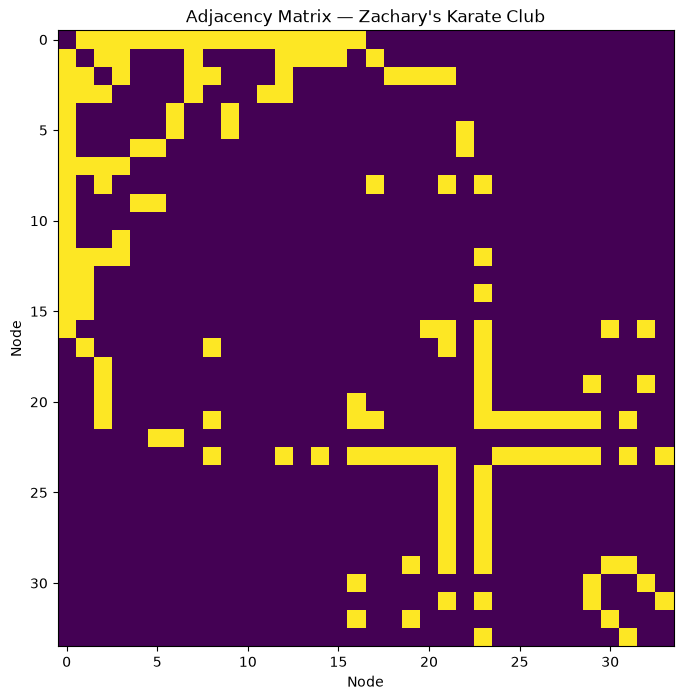

In [17]:
plt.figure(figsize=(8, 8))
plt.imshow(adjacency_df, interpolation="nearest", aspect="equal")
plt.title("Adjacency Matrix — Zachary's Karate Club")
plt.xlabel("Node")
plt.ylabel("Node")
plt.show()

## <font color="red"><b>Exercise 7</b></font>

1. Why is the adjacency matrix symmetric?
2. Why should its diagonal contain zeros?
3. Find $A_{ij}$ for one pair of connected nodes and one pair of unconnected nodes.
4. Explain how the degree of a node can be obtained from one row of the adjacency matrix.

## <font color="green"><b>Exercise 7</b></font>

1. Because the relations are undirect, this makes that a connection between A and B is the same the other way.
2. if the diagonal contains any value we would have slef-loops, is important to have the diaonal of zeros.
3. Find $A_{ij}$ for one pair of connected nodes: A21 (Actor 2 and MR Hi) and one pair of unconnected nodes A25 (Actor 2 and Actor 5).
4. We only need to sume the number of ones in a row to know the degree of this node, it shows the number of connection to other nodes.

## 6.0. Clustering coefficient

In a social network, a high clustering coefficient suggests a tightly interconnected local friendship circle.
Equivalent definitions 
- The *clustering coefficient* measures the tendency of a node's neighbors to be connected to one another.
- The *local clustering coefficient* of a node $i$ measures how close its neighbours are to forming a complete clique:


For node $i$,

$C_i = \frac{2T_i}{k_i(k_i-1)}$


where:

- $T_i$ = $T_i$ is the number of triangles that include $i$,
- $k_i$ = degree of node $i$.


The *global clustering coefficient* (or average clustering) is the mean of $C_i$ over all nodes.


### 6.1. Why clustering matters: real-world intuition

The clustering coefficient is particularly meaningful in social systems because social relationships often form **triangles**.

### Intuition
- **Friendship / school networks:** if Alice is friends with Bob and Alice is friends with Carol, Bob and Carol are also more likely to know each other.
- **Workplace networks:** people in the same project team or department often form densely connected local groups.
- **Scientific collaboration:** if researcher A collaborates with both B and C, B and C may also collaborate.
- **Online social networks:** mutual-friend recommendations exploit this tendency toward triangle closure.
- **Karate Club:** members of the same social faction form many triangles, so local clustering can reveal cohesive neighborhoods.
- **Contrast case – pure random or technological networks**  
   - Power-grid connections or random Erdős–Rényi graphs have clustering close to zero.  
   - Internet router graphs also show low clustering.  

A high clustering coefficient therefore indicates **local cohesion**: a node's neighbors tend to be connected with one another rather than forming independent relationships only through the focal node.


###  Below is an example of why the clustering coefficient matters for understanding a network.
How many **triangles** can be expected in:
- Frienship network
- Romantic network.
- Small World Model

<div style="display: flex; justify-content: space-around; align-items: center;">
    <img src="ClusteringCoeff.png" width="30%">
    <img src="SocialNetworksAuthors.png" width="25%">
    <img src="connected.jpg" width="5%">
     <img src="SmallWorld.jpg" width="40%">
</div>

#### 6.2 Triangles that involve each node

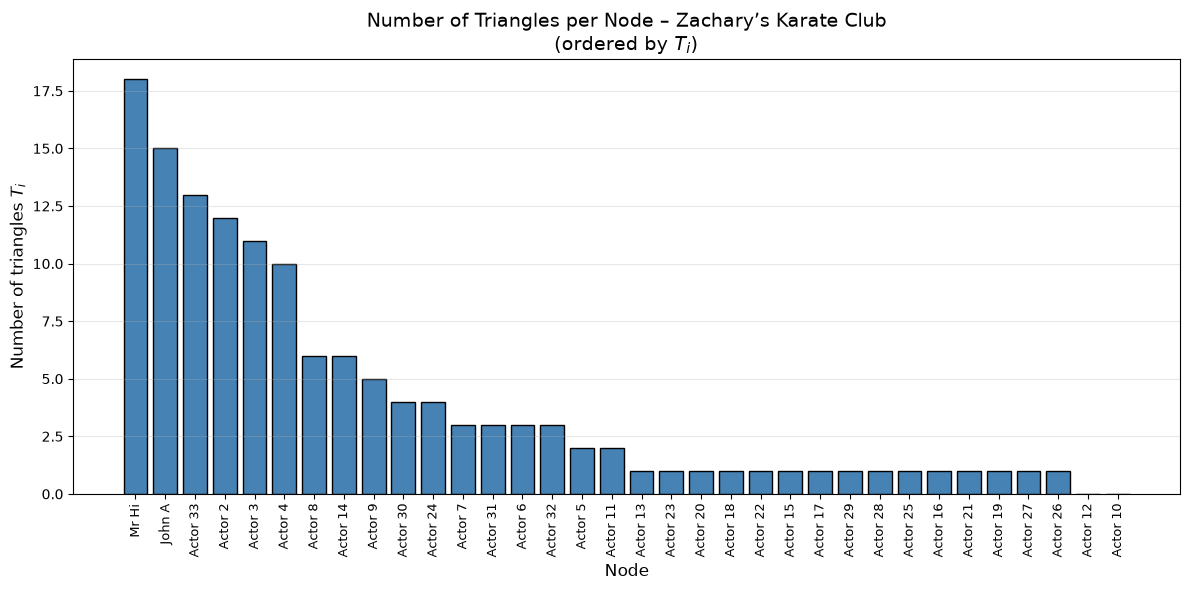

In [18]:
# Number of triangles T_i for each node (triangles including node i)
triangles = nx.triangles(G)
tri_series = pd.Series(triangles).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Bar plot (histogram-style) of number of triangles per node
bars = plt.bar(range(len(tri_series)), tri_series.values, color="steelblue", edgecolor="black")

# Vertical node labels
plt.xticks(range(len(tri_series)), tri_series.index, rotation=90, fontsize=9)

plt.ylabel("Number of triangles $T_i$", fontsize=12)
plt.xlabel("Node", fontsize=12)
plt.title("Number of Triangles per Node – Zachary’s Karate Club\n(ordered by $T_i$)", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### 6.2  Compute the clustering coefficient.
- i.e. divide by ${k_i(k_i-1)}/2$
- What is the meaning of ${k_i(k_i-1)}/2$? The number of posible conections betwwen the nodes of ${k_i}$

In [ ]:
node_metrics = (
    pd.DataFrame({
        "node": list(G.nodes()),
        "degree": [G.degree(n) for n in G.nodes()],
        "clustering_coefficient": [nx.clustering(G, n) for n in G.nodes()]
    })
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)

node_metrics.head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
node,John A,Mr Hi,Actor 33,Actor 3,Actor 2,Actor 4,Actor 32,Actor 24,Actor 14,Actor 9,Actor 31,Actor 7,Actor 8,Actor 30,Actor 28
degree,17,16,12,10,9,6,6,5,5,5,4,4,4,4,4
clustering_coefficient,0.110294,0.15,0.19697,0.244444,0.333333,0.666667,0.2,0.4,0.6,0.5,0.5,0.5,1.0,0.666667,0.166667


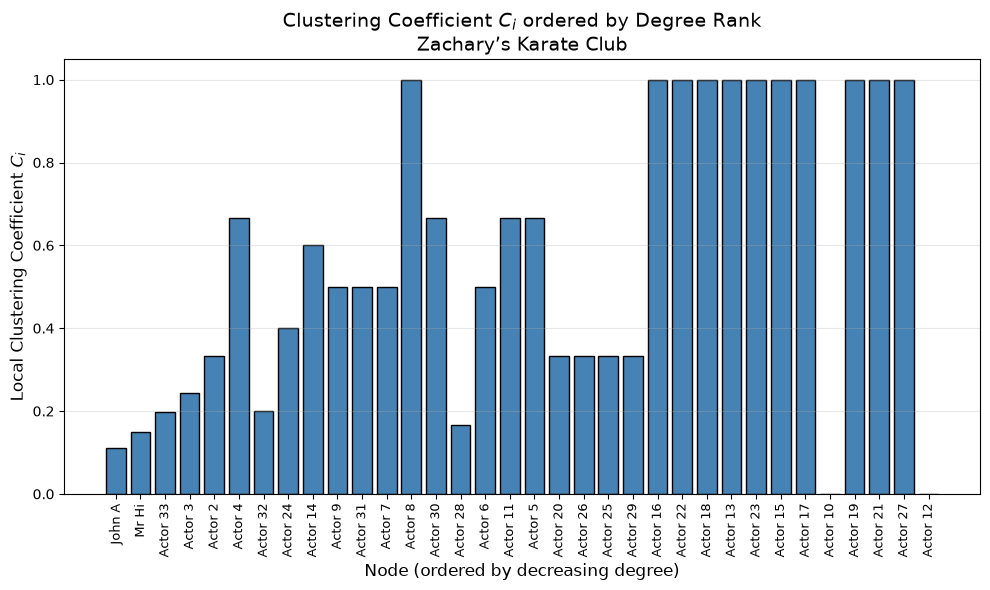

In [20]:


# Ensure the table is sorted by degree (descending)
node_metrics_sorted = node_metrics.sort_values("degree", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))

# Bar plot of clustering coefficient
plt.bar(range(len(node_metrics_sorted)), 
        node_metrics_sorted["clustering_coefficient"], 
        color="steelblue", edgecolor="black")

# Vertical node labels on the x-axis
plt.xticks(range(len(node_metrics_sorted)), 
           node_metrics_sorted["node"], 
           rotation=90, fontsize=9)

plt.ylabel(r"Local Clustering Coefficient $C_i$", fontsize=12)
plt.xlabel("Node (ordered by decreasing degree)", fontsize=12)
plt.title(r"Clustering Coefficient $C_i$ ordered by Degree Rank" + "\nZachary’s Karate Club", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

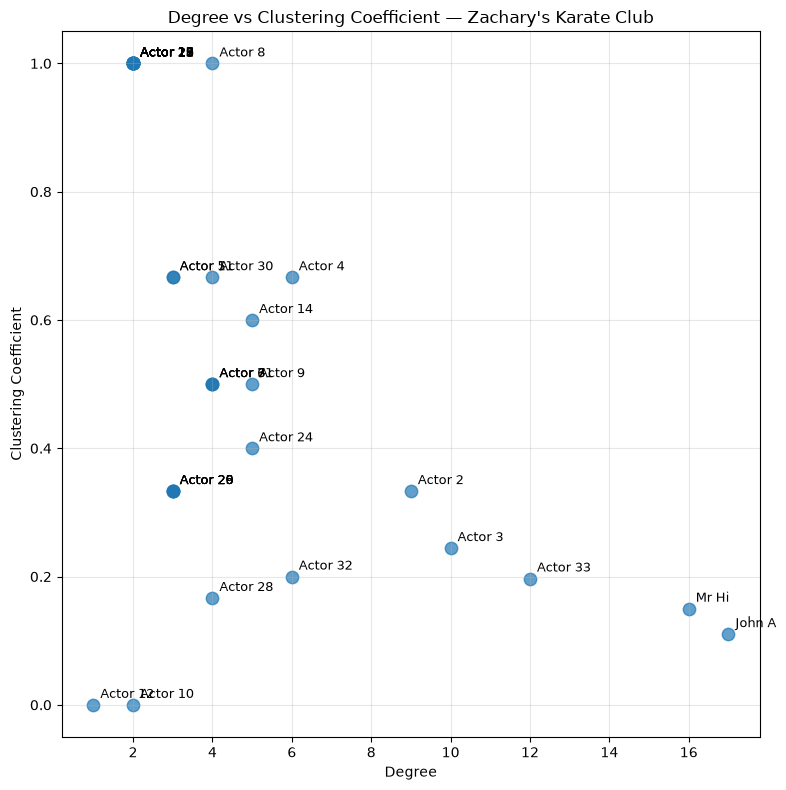

In [21]:
# Scatter plot: Degree vs Clustering Coefficient

plt.figure(figsize=(8, 8))

plt.scatter(
    node_metrics["degree"],
    node_metrics["clustering_coefficient"],
    s=80,
    alpha=0.7
)

# Add the node label to each point
for _, row in node_metrics.iterrows():
    plt.annotate(
        row["node"],
        (row["degree"], row["clustering_coefficient"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Degree")
plt.ylabel("Clustering Coefficient")
plt.title("Degree vs Clustering Coefficient — Zachary's Karate Club")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercise 8</b></font>

1. Explain to yourself your own words what is the clustering coefficient.
2. Find one node with high clustering and one node with low clustering and Explain the social meaning of these two cases.
3. Check the plot Degree vs Clustering Coefficient.  Provide a qualitative explanation of why the influencer measure, in the sense of number of followers is different from the fact that someone is integrated in the community. *Important*: **Trust** is important, argue why a high cluster indicates more trust.
4. Can a node have high degree and relatively low clustering? What would that imply about its local position?

## <font color="green"><b>Exercise 8</b></font>

1. The clustering coefficient is how many of the neighbours of a node are connected between them taking into account all the edges of this node.
2. Actor 8 has a high clustering, in fact it has a clustering of 1, so all the nodes connected to Actor 8 are connected between them. John A has a very low clustering, it has a degree of 17, so he is realated with a lot of the Karate Club members, but this members are not really related between them.
3. The number of followers and community integration measure different things. A person can have a high degree because they are connected to many people, making them an influencer, but their followers may not be connected to each other. A high clustering coefficient means that a person's connections are also strongly connected with each other, showing that they are well integrated into a community. This can indicate more trust because people who are connected to the same group are more likely to know each other and share information, making relationships more cohesive and trustworthy.
4. Yes, a node can have a high degree and relatively low clustering. This means that the node is connected to many people, but most of its neighbors are not connected to each other. Therefore, the node has a wide but less cohesive local network. It could act as a bridge between different groups rather than being strongly integrated into one community.

## 7.0. Network visualization

A network drawing is not the network itself: it is a **two-dimensional representation** of the graph.

NetworkX layout algorithms assign coordinates to nodes. A force-directed layout such as `spring_layout()` places connected nodes closer while attempting to reduce visual overlap.

The positions therefore help reveal structure, but distances in the drawing should not automatically be interpreted as physical distances.

**Objective:** Learn different ways of representing a graph, each provides a different perspective.

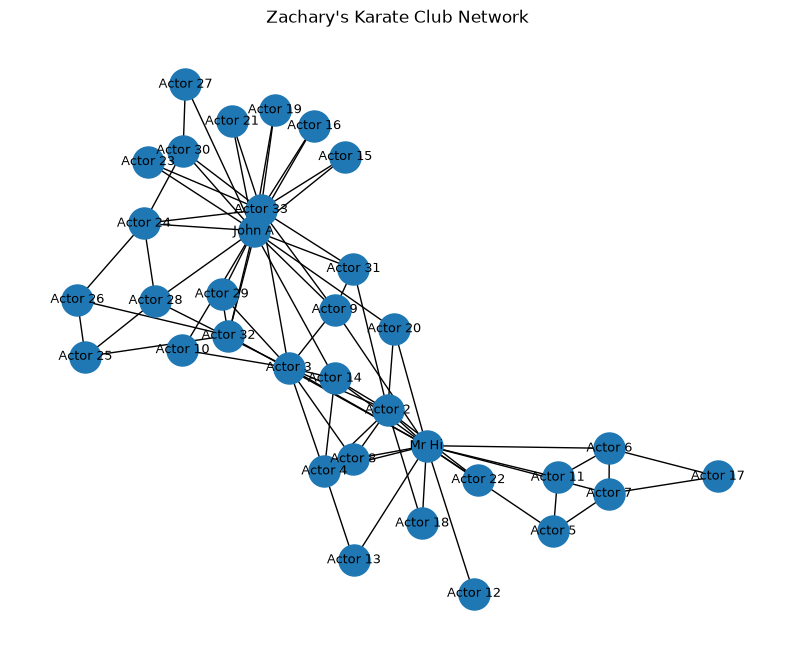

In [22]:
# Reproducible force-directed layout
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=500,
    font_size=9,
    width=1.0
)

plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

### 7.1. Visualization with node size proportional to degree

Changing node size according to degree makes highly connected members easier to identify.

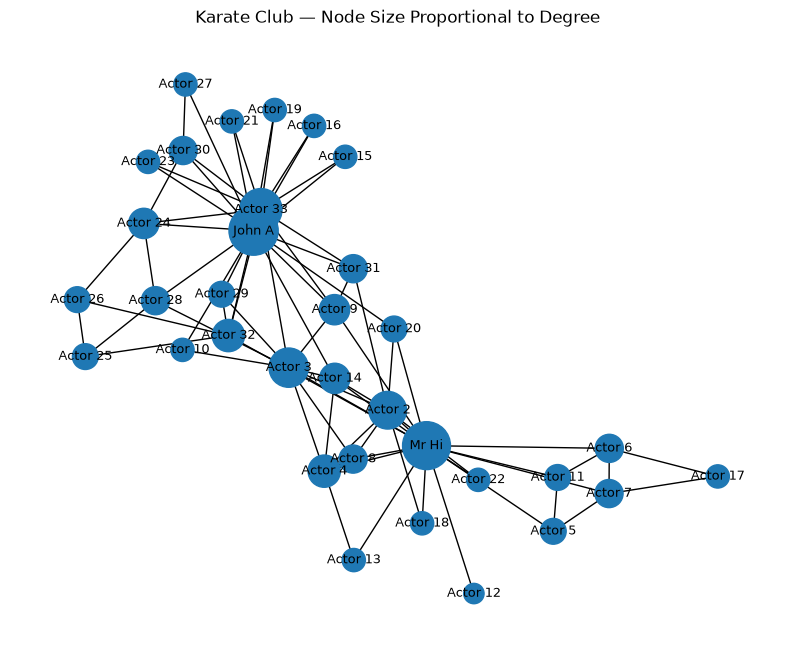

In [23]:
degrees = dict(G.degree())
node_sizes = [150 + 65 * degrees[node] for node in G.nodes()]

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Node Size Proportional to Degree")
plt.axis("off")
plt.show()

### 7.2. Alternative visualization: size and color proportional to degree

The same structural quantity can be encoded by more than one visual channel. Here, both **node size** and **node color** represent degree. Highly connected members therefore become visually prominent.

This is useful for exploratory analysis, but remember that a visual encoding is an aid to interpretation; quantitative conclusions should still be based on computed network measures.

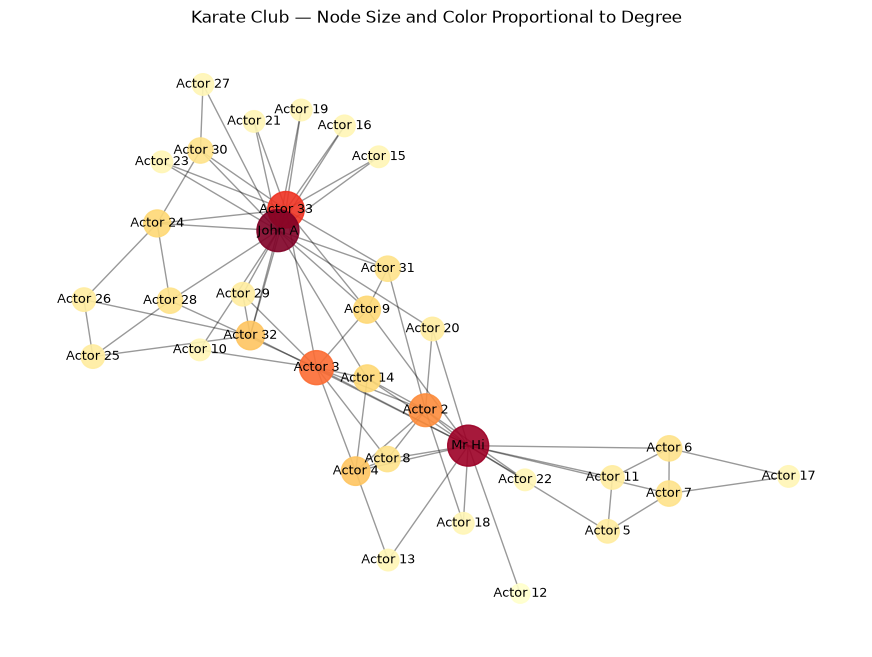

In [24]:
degrees = dict(G.degree())
node_sizes = [150 + 45 * degrees[node] for node in G.nodes()]
node_colors = [degrees[node] for node in G.nodes()]

plt.figure(figsize=(11, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club — Node Size and Color Proportional to Degree")
plt.axis("off")
plt.show()

### 7.2. Visualization with node size proportional to clustering coefficient

This view emphasizes a different structural property: local cohesion rather than number of contacts.

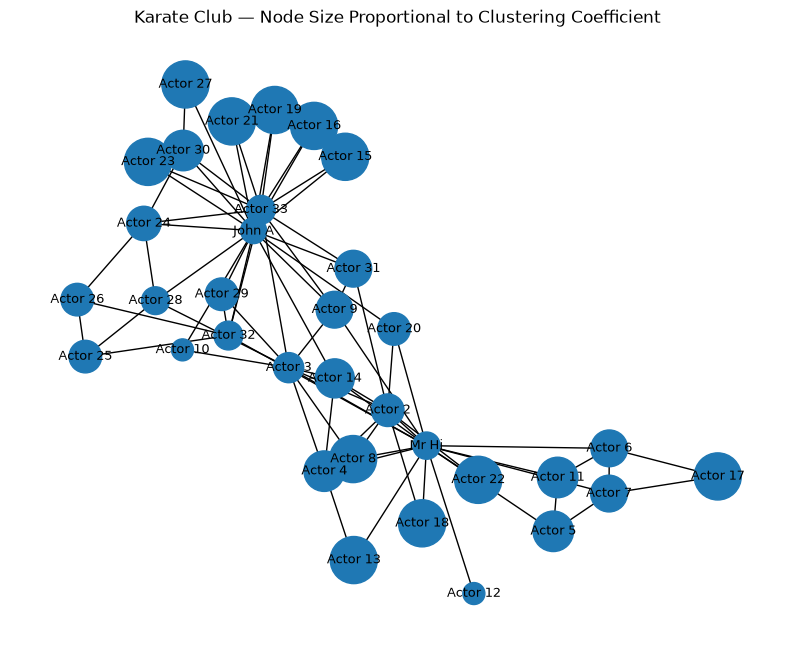

In [26]:
clustering = nx.clustering(G)

node_sizes_clustering = [
    250 + 900 * clustering[node]
    for node in G.nodes()
]

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=node_sizes_clustering,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Node Size Proportional to Clustering Coefficient")
plt.axis("off")
plt.show()

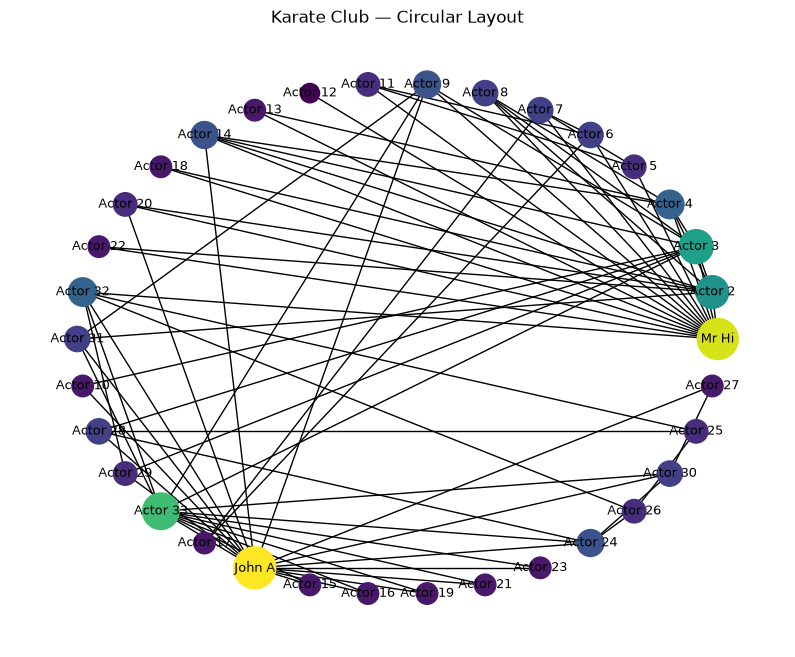

In [27]:
# Circular layout visualization
plt.figure(figsize=(10, 8))
pos_circle = nx.circular_layout(G)

# Node sizes and colours proportional to degree for readability
degrees = dict(G.degree())
node_sizes_circle = [150 + 45 * degrees[node] for node in G.nodes()]
node_colors_circle = [degrees[node] for node in G.nodes()]

nx.draw_networkx(
    G,
    pos=pos_circle,
    with_labels=True,
    node_size=node_sizes_circle,
    node_color=node_colors_circle,
    cmap=plt.cm.viridis,
    font_size=9,
    width=1.0
)

plt.title("Karate Club — Circular Layout")
plt.axis("off")
plt.show()

## <font color="red"><b>Exercise 9</b></font>

Compare the two previous figures.

1. Which nodes look important when size represents **degree**?
2. Which nodes look important when size represents **clustering coefficient**?
3. Why are the two concepts not equivalent?
4. Describe in 4–6  the club is likely to break down, from the different kind of graph representations.

## <font color="green"><b>Exercise 9</b></font>

1. Mr Hi, John A and Actor 33.
2. Actor 23, Actor 8, Actor 16, Actor 22, Actor 18, Actor 13, Actor 15, Actor 17, Actor 19, Actor 21 and Actor 27.
3. Because as seen before the degree is the number of nodes connected to your node, and cluster is the relation between this connected nodes, so for more nodes connected, less posible is to have a haigh clustering, but it can happen with communities.
4. It is posible to brake down, because as it can be seen in the clustering results there are a lot of triangles, small communities, and also, as it can be seen in the graphs, some of the nodes are really separeted from others, and the main connections between this communities are the Mr Hi, the John A and the Actor 33, and three more, but if these people decide to brake connections or leave the club, the rest of communities will ges isolated.

## <font color="red"><b>Exercise 10 — Infographic</b></font>

Create a **one-page infographic** entitled:

### *From Data to Graphs: Zachary's Karate Club*

It should visually explain in an easy to understand graphical way, the problem tackled in the practice.

findfont: Failed to find font weight medium for Arial, now using 400.


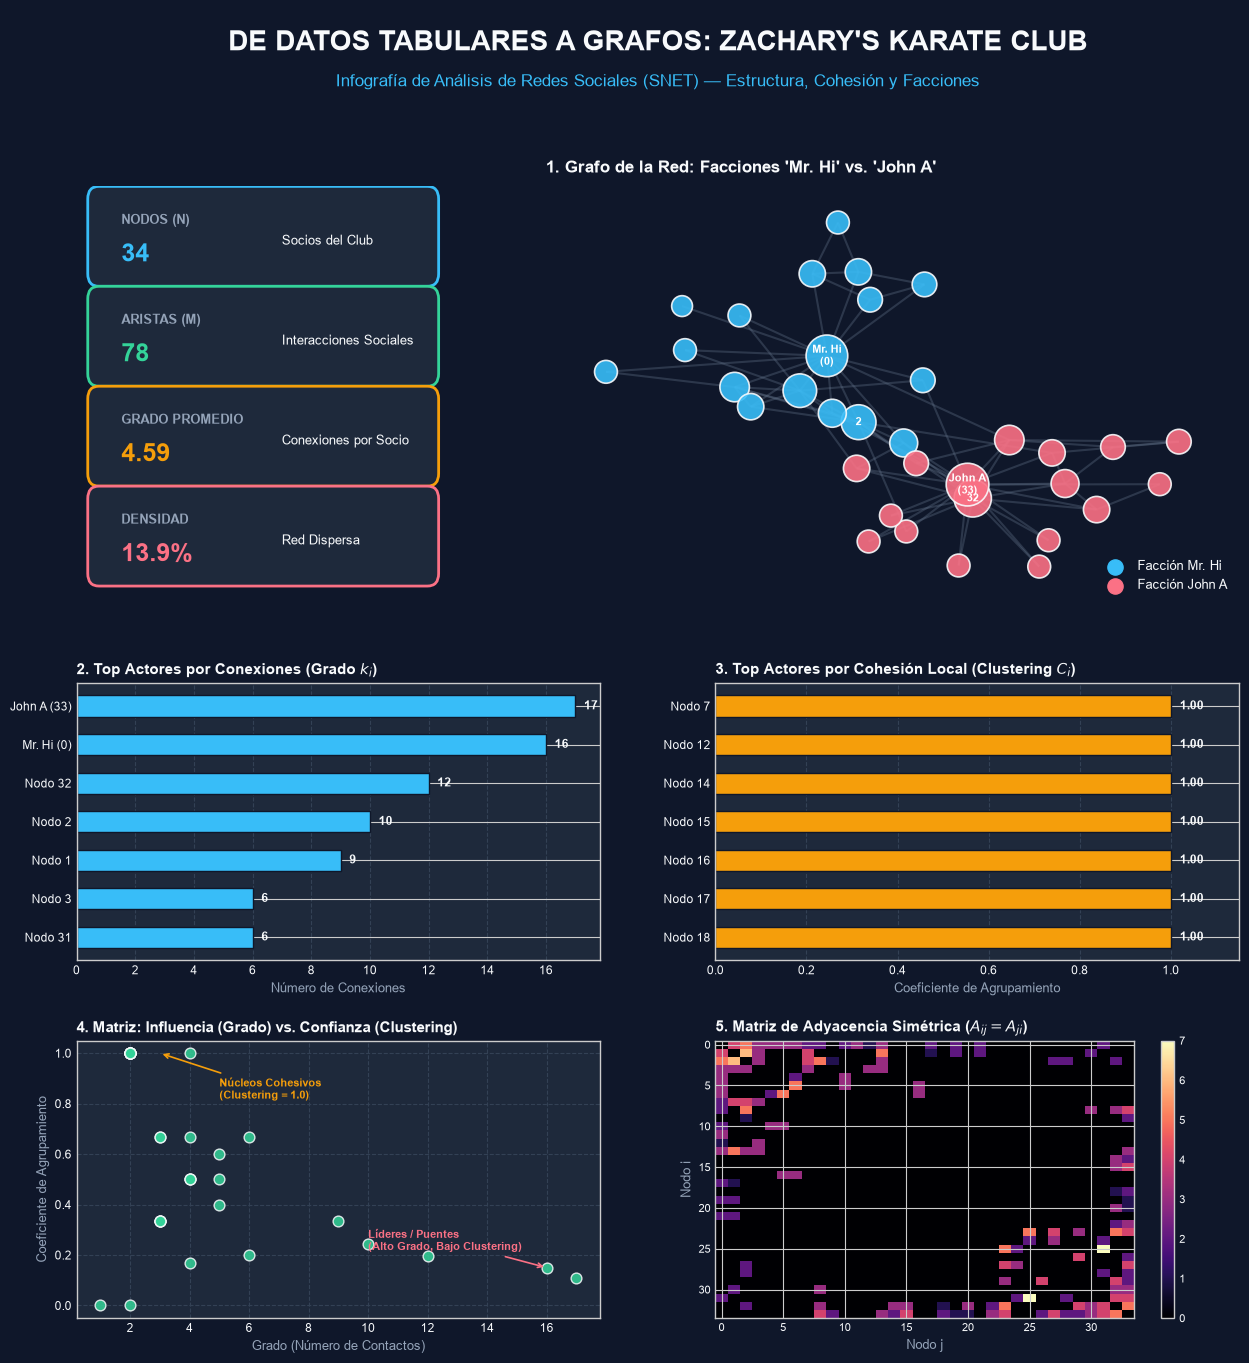

In [28]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import networkx as nx
import numpy as np
import pandas as pd

# Configuración de estilo visual oscuro y limpio
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
fig = plt.figure(figsize=(15, 17), facecolor='#0F172A')
gs = gridspec.GridSpec(
    4, 2, height_ratios=[0.35, 1.5, 1.0, 1.0], hspace=0.30, wspace=0.22
)

# Paleta de colores profesional
C_BG, C_CARD = '#0F172A', '#1E293B'
C_TEXT, C_SUBTEXT = '#F8FAFC', '#94A3B8'
C_CYAN, C_AMBER, C_ROSE, C_EMERALD = '#38BDF8', '#F59E0B', '#FB7185', '#34D399'

# Cargar el grafo de Karate Club
G = nx.karate_club_graph()
N, M = G.number_of_nodes(), G.number_of_edges()
avg_degree, density = 2 * M / N, nx.density(G)

# --- 1. BANNER DEL TÍTULO ---
ax_header = fig.add_subplot(gs[0, :])
ax_header.set_facecolor(C_BG)
ax_header.axis('off')
ax_header.text(
    0.5,
    0.65,
    "DE DATOS TABULARES A GRAFOS: ZACHARY'S KARATE CLUB",
    color=C_TEXT,
    fontsize=20,
    fontweight='bold',
    ha='center',
    va='center',
)
ax_header.text(
    0.5,
    0.25,
    "Infografía de Análisis de Redes Sociales (SNET) — Estructura, Cohesión y"
    " Facciones",
    color=C_CYAN,
    fontsize=12,
    fontweight='medium',
    ha='center',
    va='center',
)

# --- 2. TARJETAS KPI + GRAFO DE LA RED ---
gs_kpi_net = gs[1, :].subgridspec(1, 2, width_ratios=[0.35, 0.65], wspace=0.18)

# Tarjetas KPI
ax_kpis = fig.add_subplot(gs_kpi_net[0])
ax_kpis.set_facecolor(C_BG)
ax_kpis.axis('off')
kpi_data = [
    ("NODOS (N)", f"{N}", "Socios del Club", C_CYAN),
    ("ARISTAS (M)", f"{M}", "Interacciones Sociales", C_EMERALD),
    ("GRADO PROMEDIO", f"{avg_degree:.2f}", "Conexiones por Socio", C_AMBER),
    ("DENSIDAD", f"{density*100:.1f}%", "Red Dispersa", C_ROSE),
]
for i, (title, val, sub, col) in enumerate(kpi_data):
  y_pos = 0.78 - i * 0.24
  rect = FancyBboxPatch(
      (0.05, y_pos),
      0.90,
      0.20,
      boxstyle="round,pad=0.02,rounding_size=0.03",
      facecolor=C_CARD,
      edgecolor=col,
      linewidth=2,
      transform=ax_kpis.transAxes,
  )
  ax_kpis.add_patch(rect)
  ax_kpis.text(
      0.12,
      y_pos + 0.13,
      title,
      color=C_SUBTEXT,
      fontsize=9,
      fontweight='bold',
      transform=ax_kpis.transAxes,
  )
  ax_kpis.text(
      0.12,
      y_pos + 0.04,
      val,
      color=col,
      fontsize=18,
      fontweight='bold',
      transform=ax_kpis.transAxes,
  )
  ax_kpis.text(
      0.55,
      y_pos + 0.08,
      sub,
      color=C_TEXT,
      fontsize=9,
      ha='left',
      transform=ax_kpis.transAxes,
  )

# Grafo de Red
ax_net = fig.add_subplot(gs_kpi_net[1])
ax_net.set_facecolor(C_CARD)
ax_net.set_title(
    "1. Grafo de la Red: Facciones 'Mr. Hi' vs. 'John A'",
    color=C_TEXT,
    fontsize=12,
    pad=10,
    fontweight='bold',
    loc='left',
)
pos = nx.spring_layout(G, seed=42)
node_clubs = [G.nodes[n]['club'] for n in G.nodes()]
node_colors = [C_CYAN if club == 'Mr. Hi' else C_ROSE for club in node_clubs]
degrees = dict(G.degree())
node_sizes = [180 + 45 * degrees[n] for n in G.nodes()]

nx.draw_networkx_edges(
    G, pos, ax=ax_net, alpha=0.35, edge_color='#64748B', width=1.5
)
nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax_net,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    edgecolors='#F8FAFC',
    linewidths=1.2,
)

labels = {0: 'Mr. Hi\n(0)', 33: 'John A\n(33)'}
for n in G.nodes():
  if degrees[n] >= 10 and n not in [0, 33]:
    labels[n] = str(n)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    ax=ax_net,
    font_size=8,
    font_color='#FFFFFF',
    font_weight='bold',
)
ax_net.scatter([], [], c=C_CYAN, s=120, label='Facción Mr. Hi')
ax_net.scatter([], [], c=C_ROSE, s=120, label='Facción John A')
ax_net.legend(
    loc='lower right',
    facecolor=C_BG,
    edgecolor=C_SUBTEXT,
    labelcolor=C_TEXT,
    fontsize=9,
)
ax_net.axis('off')

# --- 3. GRÁFICOS DE BARRAS (GRADO Y CLUSTERING) ---
# Top Grado
top_deg = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:7]
nodes_deg = [
    f"Nodo {n}" if n not in [0, 33] else ("Mr. Hi (0)" if n == 0 else "John A (33)")
    for n, d in top_deg
]
vals_deg = [d for n, d in top_deg]

ax_bar1 = fig.add_subplot(gs[2, 0])
ax_bar1.set_facecolor(C_CARD)
ax_bar1.set_title(
    "2. Top Actores por Conexiones (Grado $k_i$)",
    color=C_TEXT,
    fontsize=11,
    fontweight='bold',
    loc='left',
)
bars1 = ax_bar1.barh(
    nodes_deg[::-1], vals_deg[::-1], color=C_CYAN, edgecolor=C_BG, height=0.55
)
ax_bar1.set_xlabel("Número de Conexiones", color=C_SUBTEXT, fontsize=9)
ax_bar1.tick_params(colors=C_TEXT, labelsize=8.5)
ax_bar1.grid(axis='x', color='#334155', linestyle='--')
for bar in bars1:
  width = bar.get_width()
  ax_bar1.text(
      width + 0.3,
      bar.get_y() + bar.get_height() / 2,
      f"{int(width)}",
      va='center',
      ha='left',
      color=C_TEXT,
      fontweight='bold',
      fontsize=8.5,
  )

# Top Clustering
clustering = nx.clustering(G)
top_clust = sorted(clustering.items(), key=lambda x: x[1], reverse=True)[:7]
nodes_clust = [f"Nodo {n}" for n, c in top_clust]
vals_clust = [c for n, c in top_clust]

ax_bar2 = fig.add_subplot(gs[2, 1])
ax_bar2.set_facecolor(C_CARD)
ax_bar2.set_title(
    "3. Top Actores por Cohesión Local (Clustering $C_i$)",
    color=C_TEXT,
    fontsize=11,
    fontweight='bold',
    loc='left',
)
bars2 = ax_bar2.barh(
    nodes_clust[::-1], vals_clust[::-1], color=C_AMBER, edgecolor=C_BG, height=0.55
)
ax_bar2.set_xlabel("Coeficiente de Agrupamiento", color=C_SUBTEXT, fontsize=9)
ax_bar2.tick_params(colors=C_TEXT, labelsize=8.5)
ax_bar2.set_xlim(0, 1.15)
ax_bar2.grid(axis='x', color='#334155', linestyle='--')
for bar in bars2:
  width = bar.get_width()
  ax_bar2.text(
      width + 0.02,
      bar.get_y() + bar.get_height() / 2,
      f"{width:.2f}",
      va='center',
      ha='left',
      color=C_TEXT,
      fontweight='bold',
      fontsize=8.5,
  )

# --- 4. SCATTER PLOT Y MATRIZ DE ADYACENCIA ---
# Scatter: Grado vs Clustering
ax_scat = fig.add_subplot(gs[3, 0])
ax_scat.set_facecolor(C_CARD)
ax_scat.set_title(
    "4. Matriz: Influencia (Grado) vs. Confianza (Clustering)",
    color=C_TEXT,
    fontsize=11,
    fontweight='bold',
    loc='left',
)
deg_vals = list(degrees.values())
clust_vals = [clustering[n] for n in G.nodes()]
ax_scat.scatter(
    deg_vals,
    clust_vals,
    color=C_EMERALD,
    s=60,
    alpha=0.85,
    edgecolors='#F8FAFC',
)
ax_scat.set_xlabel("Grado (Número de Contactos)", color=C_SUBTEXT, fontsize=9)
ax_scat.set_ylabel(
    "Coeficiente de Agrupamiento", color=C_SUBTEXT, fontsize=9
)
ax_scat.tick_params(colors=C_TEXT, labelsize=8.5)
ax_scat.grid(color='#334155', linestyle='--')

ax_scat.annotate(
    "Líderes / Puentes\n(Alto Grado, Bajo Clustering)",
    xy=(16, clustering[0]),
    xytext=(10, 0.22),
    arrowprops=dict(arrowstyle="->", color=C_ROSE, lw=1.2),
    color=C_ROSE,
    fontweight='bold',
    fontsize=8,
)
ax_scat.annotate(
    "Núcleos Cohesivos\n(Clustering = 1.0)",
    xy=(3, 1.0),
    xytext=(5, 0.82),
    arrowprops=dict(arrowstyle="->", color=C_AMBER, lw=1.2),
    color=C_AMBER,
    fontweight='bold',
    fontsize=8,
)

# Matriz de Adyacencia
ax_adj = fig.add_subplot(gs[3, 1])
ax_adj.set_facecolor(C_CARD)
ax_adj.set_title(
    "5. Matriz de Adyacencia Simétrica ($A_{ij} = A_{ji}$)",
    color=C_TEXT,
    fontsize=11,
    fontweight='bold',
    loc='left',
)
adj_matrix = nx.to_numpy_array(G)
im = ax_adj.imshow(adj_matrix, cmap='magma', aspect='auto')
ax_adj.set_xlabel("Nodo j", color=C_SUBTEXT, fontsize=9)
ax_adj.set_ylabel("Nodo i", color=C_SUBTEXT, fontsize=9)
ax_adj.tick_params(colors=C_TEXT, labelsize=8)
cbar = plt.colorbar(im, ax=ax_adj)
cbar.ax.tick_params(labelsize=8, colors=C_TEXT)

plt.show()

## <font color="red"><b>Exercise 11 — Executive Summary</b></font>

Write an **executive summary of approximately 250–350 words** that could be understood by a reader who is short of time, and wants to get the idea of what was done.

## <font color="green"><b>Exercise 11 — Executive Summary</b></font>

### Overview &amp; Methodology 
This project transforms raw tabular relational data into an undirected social graph using Python, pandas, and NetworkX to evaluate the structural topology of Zachary’s Karate Club. By modeling 34 club members as nodes and 78 social interactions as edges, we bridged data inspection with complex network theory to uncover how individual connections drive group cohesion and structural fragmentation. 

### Key Milestones &amp; Analytical Findings 
* **Data Ingestion &amp; Integrity:** Standardized the edge-list table, confirming zero missing values, duplicates, or self-loops, establishing a clean undirected simple graph $G(V,E)$. 

* **Global Topology Metrics:** Calculated an average degree of $\\langle k \\rangle = 4.59$ and a low graph density of $13.9\\%$, proving that the network is sparse and highly conducive to modular community formation. 

* **Influencers vs. Cohesive Cliques:** Identified major hubs ("Mr. Hi" and "John A.") who possess high degree centrality but low local clustering, acting as global connectors. Conversely, peripheral members exhibited local clustering coefficients up to $1.0$, signaling tightly knit, high-trust micro-communities. \* 

**Visual Structural Mapping:** Utilized force-directed layout algorithms (*spring_layout*) to visually highlight the emergent split between opposing leadership poles prior to the real-world group fission. 

### Future Work &amp; Recommendations 
1\. **Algorithmic Fission Prediction:** Implement community detection algorithms (e.g., Girvan-Newman or Louvain modularity) to quantitatively evaluate the exact historical split into two factions. 

2\. **Advanced Centrality Measures:** Compute Betweenness and Eigenvector centralities to pinpoint crucial information brokers and boundary-spanning bridge nodes. 

3\. **Weighted &amp; Dynamic Modeling:** Integrate interaction frequency as edge weights and model time-series graph updates to analyze conflict escalation over time.